# Import libraries


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import numpy as np
import scipy.stats as stats
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize as vi_tokenizer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Specify the path to your file in Google Drive
file_path = '/content/drive/MyDrive/Silver_data.csv'

# Read the file
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Name,Address,Distance_to_DownTown,Distance_to_Beach,Price,Taxes,Point,Evaluate,Stars,Rates_Quantity,...,count_nearest_airport,distance_to_nearest_airport,day,month,is_weekend,day_range,is_special_day,Accommodation_Type,Room_Level,Room/Bed Quantity
0,corgi house,da nang,0.4,1.7,475000.0,0.0,8.1,2,0.0,48.0,...,2,9.0,15,5,0,15,0,phòng,superior,1 giường đôi
1,ngoc bich hotel,da nang,1.8,0.0,242338.0,32242.0,8.0,2,3.0,1555.0,...,2,6.0,15,5,0,15,0,phòng,superior,không rõ
2,la belle vie boutique hotel,da nang,1.3,2.4,450000.0,58500.0,8.9,3,4.0,430.0,...,2,5.0,15,5,0,15,0,phòng,superior,1 giường đôi
3,lada house,da nang,0.0,2.4,806841.0,0.0,9.0,4,0.0,407.0,...,2,6.0,15,5,0,15,0,phòng,deluxe,1 giường đôi
4,dana boutique hotel apartment,da nang,1.4,0.0,524200.0,70205.0,8.8,3,4.0,147.0,...,2,9.0,15,5,0,15,0,studio,khác,1 giường


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274859 entries, 0 to 274858
Data columns (total 39 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Name                         274810 non-null  object 
 1   Address                      274859 non-null  object 
 2   Distance_to_DownTown         274859 non-null  float64
 3   Distance_to_Beach            274859 non-null  float64
 4   Price                        274859 non-null  float64
 5   Taxes                        274859 non-null  float64
 6   Point                        274859 non-null  float64
 7   Evaluate                     274859 non-null  int64  
 8   Stars                        274859 non-null  float64
 9   Rates_Quantity               274859 non-null  float64
 10  view_to_beach                274859 non-null  float64
 11  view_to_city                 274859 non-null  float64
 12  view_to_mountain             274859 non-null  float64
 13 

In [ ]:
#!pip install ydata-profiling

In [ ]:
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Hotel Report", explorative=True)
# profile.to_file("Delay_report.html")

# Cộng cột Taxes và Price, sau đó drop cột taxes

In [ ]:
df['Price'] = df['Price'] + df['Taxes']
df = df.drop('Taxes', axis=1)

# Phân phối của cột giá

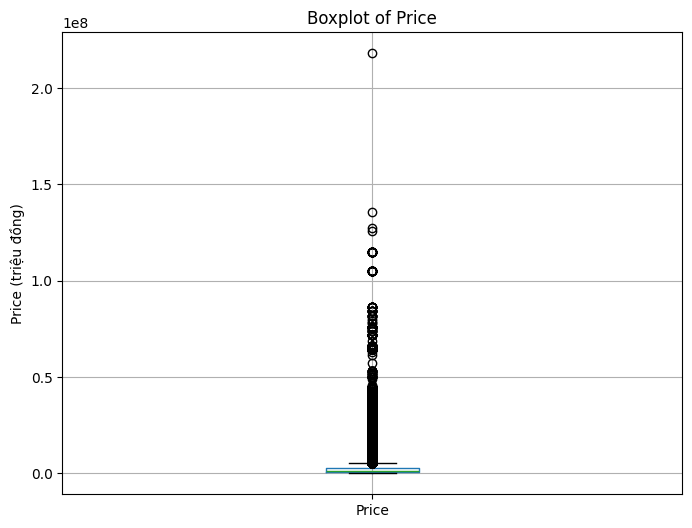

In [ ]:
import matplotlib.pyplot as plt
# Vẽ boxplot của cột 'Price'
plt.figure(figsize=(8, 6))
df.boxplot(column='Price')
plt.title('Boxplot of Price')
plt.ylabel('Price (triệu đồng)')
plt.show()

 # Kiểm tra và chia ra 2 tập dữ liệu và dựa trên tứ phân vị ở cột giá :

In [ ]:
# Chia df thành 2 df tên df_1 và df_2 với df_1 chứa những dòng có giá trị cột Price lớn hơn 3 lần tứ phân vị thứ 3 hoặc bé hơn 3 lần tứ phân vị thứ nhất và df_2 chứa những dòng còn lại

# Calculate quartiles
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

# Define thresholds for outliers
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Split the DataFrame
df_with_outlier = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
df = df[~((df['Price'] < lower_bound) | (df['Price'] > upper_bound))]


In [ ]:
print(lower_bound)
print(upper_bound)

-2072631.5
5588276.5


In [ ]:
df.head()

,Name,Address,Distance_to_DownTown,Distance_to_Beach,Price,Point,Evaluate,Stars,Rates_Quantity,view_to_beach,...,count_nearest_airport,distance_to_nearest_airport,day,month,is_weekend,day_range,is_special_day,Accommodation_Type,Room_Level,Room/Bed Quantity
0,corgi house,da nang,0.4,1.7,475000.0,8.1,2,0.0,48.0,0.0,...,2,9.0,15,5,0,15,0,phòng,superior,1 giường đôi
1,ngoc bich hotel,da nang,1.8,0.0,274580.0,8.0,2,3.0,1555.0,0.0,...,2,6.0,15,5,0,15,0,phòng,superior,không rõ
2,la belle vie boutique hotel,da nang,1.3,2.4,508500.0,8.9,3,4.0,430.0,0.0,...,2,5.0,15,5,0,15,0,phòng,superior,1 giường đôi
3,lada house,da nang,0.0,2.4,806841.0,9.0,4,0.0,407.0,0.0,...,2,6.0,15,5,0,15,0,phòng,deluxe,1 giường đôi
4,dana boutique hotel apartment,da nang,1.4,0.0,594405.0,8.8,3,4.0,147.0,0.0,...,2,9.0,15,5,0,15,0,studio,khác,1 giường


# Thực hiện EDA (Exploration Data Analysis) trên df

## Phân phối cột giá ở df

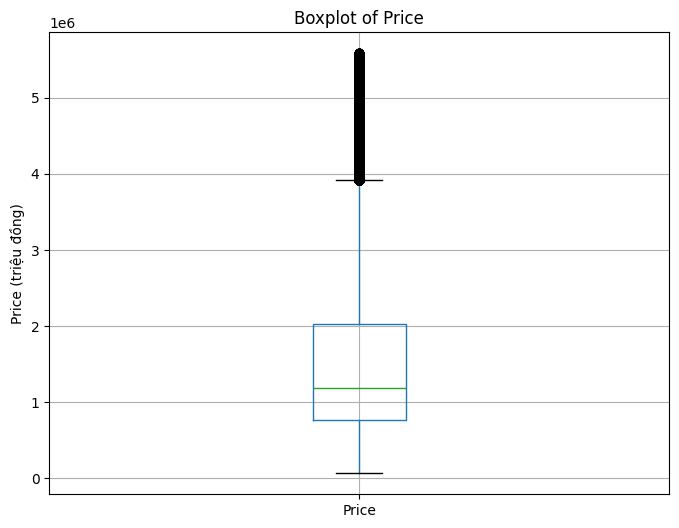

In [ ]:
plt.figure(figsize=(8, 6))
df.boxplot(column='Price')
plt.title('Boxplot of Price')
plt.ylabel('Price (triệu đồng)')
plt.show()

## Kiểm tra độ tương quan giữa các thuộc tính continueous

In [ ]:
continuous_cols=[ 'Distance_to_DownTown', 'Distance_to_Beach',
       'Point', 'Evaluate', 'Stars', 'tourist_spot', 'eat_drink_spot', 'beachs', 'staff',
       'convenient', 'clean', 'comfort', 'worthwhile', 'destination',
       'Adults', 'Children', 'count_nearest_airport',
       'distance_to_nearest_airport', 'day', 'month']

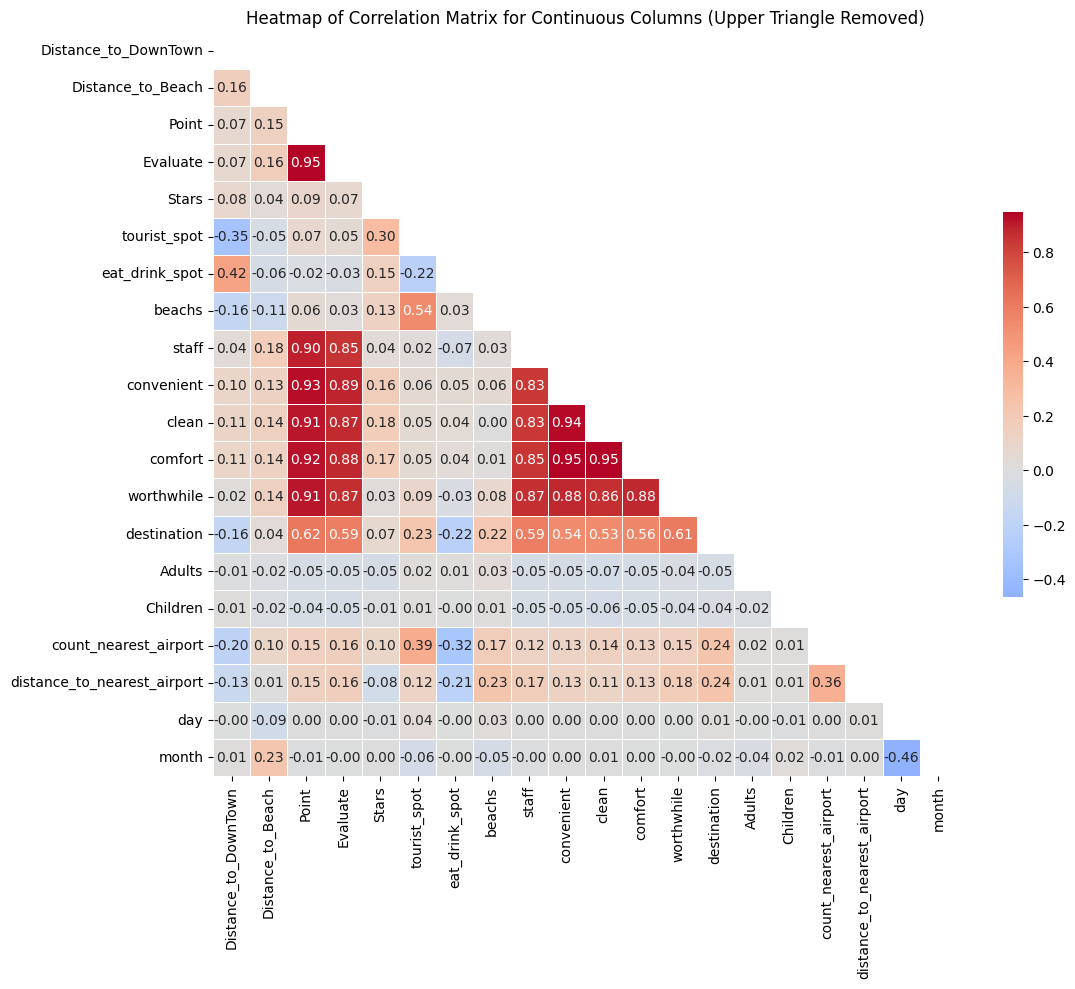

In [ ]:
continuous_df=df[continuous_cols]
# Calculate the correlation matrix
correlation_matrix = continuous_df.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Draw the heatmap with the mask and aspect ratio
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Heatmap of Correlation Matrix for Continuous Columns (Upper Triangle Removed)')
plt.show()


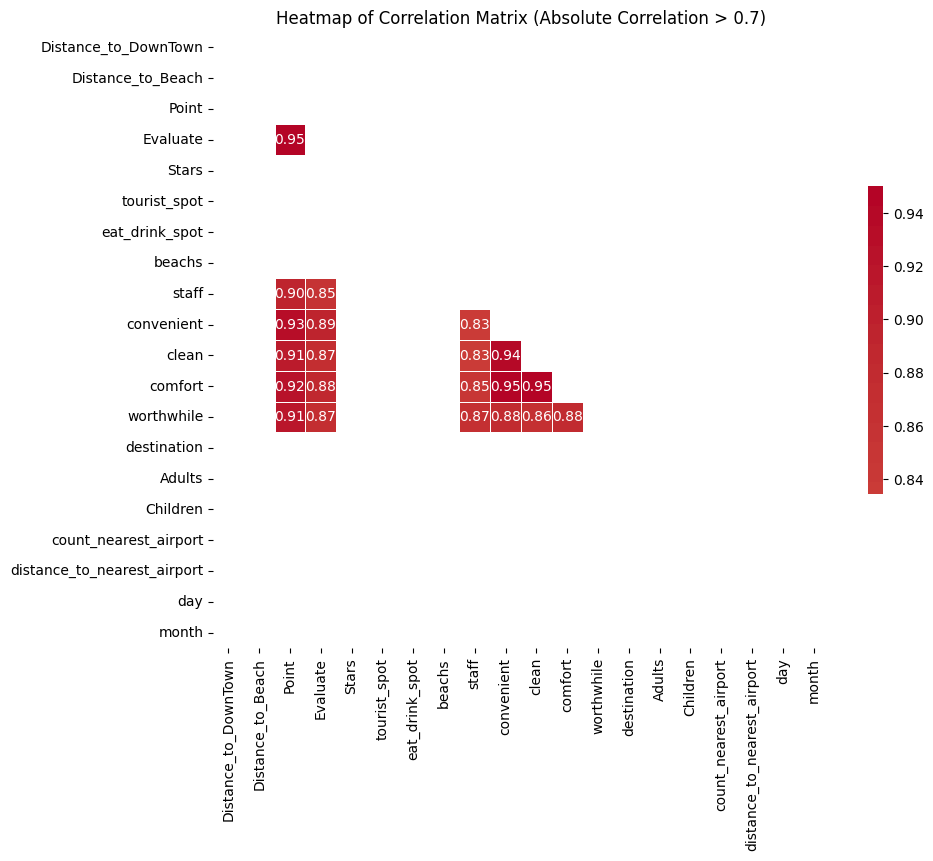

Columns remaining after filtering based on correlation > 0.7:


['Distance_to_DownTown',
 'Distance_to_Beach',
 'Point',
 'Evaluate',
 'Stars',
 'tourist_spot',
 'eat_drink_spot',
 'beachs',
 'staff',
 'convenient',
 'clean',
 'comfort',
 'worthwhile',
 'destination',
 'Adults',
 'Children',
 'count_nearest_airport',
 'distance_to_nearest_airport',
 'day',
 'month']

In [ ]:
# prompt: chỉ giữ lại những ô >0.7 và vẽ lại ma trận tương quan, những cột nào không liên quan xóa đi

# Keep only correlations greater than 0.7 (absolute value)
filtered_correlation_matrix = correlation_matrix[abs(correlation_matrix) > 0.7].dropna(axis=1, how='all').dropna(axis=0, how='all')

# Generate a mask for the upper triangle of the filtered matrix
mask_filtered = np.triu(np.ones_like(filtered_correlation_matrix, dtype=bool))

# Set up the matplotlib figure for the filtered heatmap
plt.figure(figsize=(10, 8))

# Draw the heatmap with the mask and aspect ratio
sns.heatmap(filtered_correlation_matrix, mask=mask_filtered, annot=True, cmap='coolwarm', fmt=".2f", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Heatmap of Correlation Matrix (Absolute Correlation > 0.7)')
plt.show()

# Get the columns that remain after filtering
remaining_cols = filtered_correlation_matrix.columns.tolist()

# You can now work with the original dataframe keeping only these columns
df_filtered_cols = df[remaining_cols]

print("Columns remaining after filtering based on correlation > 0.7:")
remaining_cols


### Nhìn vào biểu đồ trên, ta thấy các cột **evaluate, staff, convenient, clean, comfort, worthwhile** có độ tương quan lớn hơn 0.8 với cột Point nên ta chỉ giữ lại cột Point và bỏ 6 cột còn lại

## Kiểm tra độ tương quan giữa các thuộc tính continueous và target

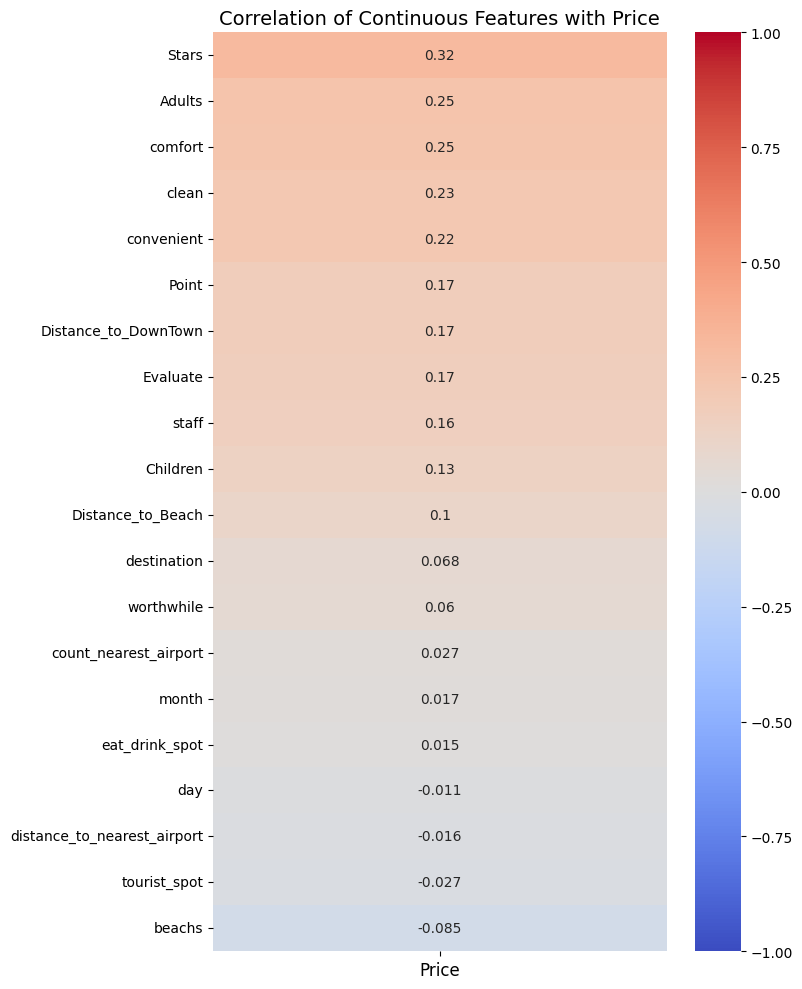

In [ ]:
# Tính tương quan với Price
correlations = df[continuous_cols + ['Price']].corr()['Price'].drop('Price')
correlations_sorted = correlations.sort_values(ascending=False)

# Vẽ heatmap đơn giản, nằm ngang
plt.figure(figsize=(8, 10))
sns.heatmap(correlations_sorted.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, cbar=True)

plt.title('Correlation of Continuous Features with Price', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## Kiểm định những cột binary với cột giá

In [ ]:
test_col=['view_to_beach','view_to_city','view_to_mountain','view_to_river','eaves','pool','parking','is_weekend','is_special_day','airport_shuttle','Price']
df_to_test=df[test_col]

In [ ]:
df_to_test

,view_to_beach,view_to_city,view_to_mountain,view_to_river,eaves,pool,parking,is_weekend,is_special_day,airport_shuttle,Price
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,1.0,475000.0
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0,0,1.0,274580.0
2,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0,0,1.0,508500.0
3,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0,0,1.0,806841.0
4,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0,0,1.0,594405.0
...,...,...,...,...,...,...,...,...,...,...,...
274853,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0.0,1100000.0
274854,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,1015534.0
274855,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,2975000.0
274857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,2300000.0


Lấy ra những cột cần kiểm định

In [ ]:
test_col.remove('Price')
binary_cols=test_col

### Vẽ phân phối của 2 nhóm 0 và 1 trong mỗi cột đối với cột Price để xem sự khác biệt

<ipython-input-25-3794553311>:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['0', '1']);
<ipython-input-25-3794553311>:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['0', '1']);
<ipython-input-25-3794553311>:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['0', '1']);
<ipython-input-25-3794553311>:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=['0',

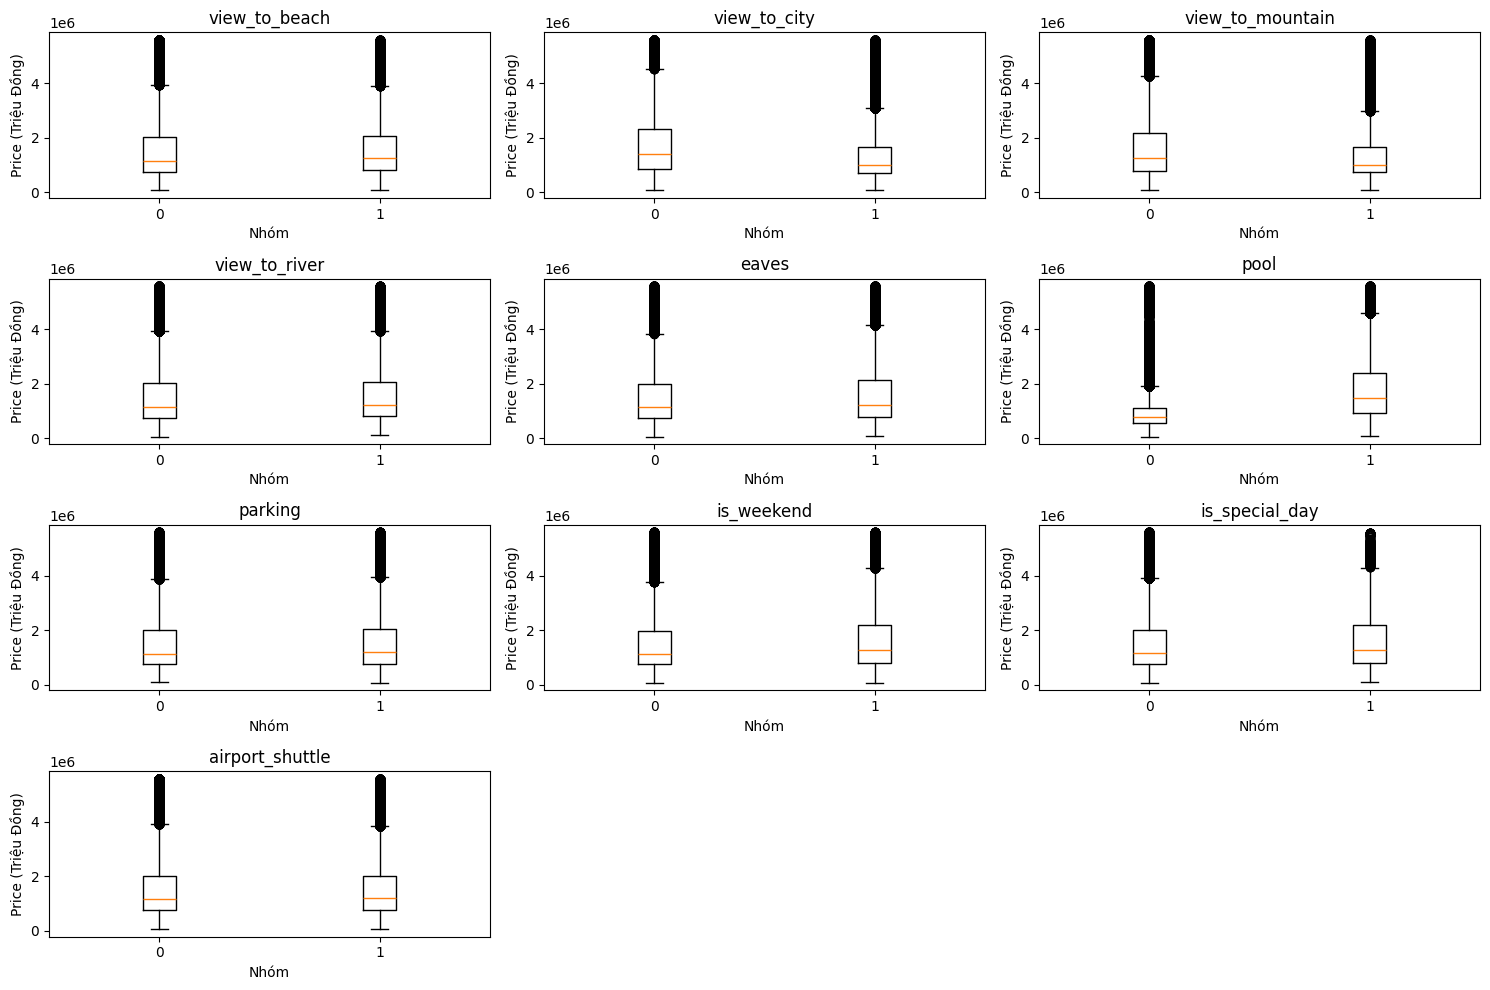

In [ ]:
# Tạo subplot grid 3x3 (nhiều hơn số cột để dư ra)
fig, axes = plt.subplots(4, 3, figsize=(15, 10))  # 3 hàng x 3 cột
axes = axes.flatten()  # Chuyển thành list 1 chiều

# Vẽ từng boxplot
for i, col in enumerate(binary_cols):
    ax = axes[i]
    data0 = df_to_test[df_to_test[col] == 0]['Price']
    data1 = df_to_test[df_to_test[col] == 1]['Price']

    ax.boxplot([data0, data1], labels=['0', '1']);
    ax.set_title(col)
    ax.set_xlabel('Nhóm')
    ax.set_ylabel('Price (Triệu Đồng)')

# Ẩn các subplot dư (nếu có)
for j in range(len(binary_cols), len(axes)):
    fig.delaxes(axes[j])  # hoặc axes[j].axis('off')

plt.tight_layout()
plt.show()


Nhìn vào phân phối price giữa các nhóm trong từng thuộc tính, ta có thể thấy :
- Thuộc tính view_to_mountain,pool,view_to_city có sự khác biệt phân phối Price giữa 2 nhóm 0 và 1
- Các thuộc tính còn lại đều ít có sự khác biệt rõ ràng giữa 2 nhóm

### Trung bình của 2 nhóm 0 và 1 trong mỗi cột

In [ ]:
for col in binary_cols:
    print(f"Mean Price for {col}:")
    print(df_to_test.groupby(col)['Price'].mean())
    print("-" * 20)


Mean Price for view_to_beach:
view_to_beach
0.0    1.550813e+06
1.0    1.600452e+06
Name: Price, dtype: float64
--------------------
Mean Price for view_to_city:
view_to_city
0.0    1.751832e+06
1.0    1.331962e+06
Name: Price, dtype: float64
--------------------
Mean Price for view_to_mountain:
view_to_mountain
0.0    1.652806e+06
1.0    1.305337e+06
Name: Price, dtype: float64
--------------------
Mean Price for view_to_river:
view_to_river
0.0    1.554229e+06
1.0    1.633390e+06
Name: Price, dtype: float64
--------------------
Mean Price for eaves:
eaves
0.0    1.534150e+06
1.0    1.636064e+06
Name: Price, dtype: float64
--------------------
Mean Price for pool:
pool
0.0    9.930935e+05
1.0    1.813212e+06
Name: Price, dtype: float64
--------------------
Mean Price for parking:
parking
0.0    1.520142e+06
1.0    1.584113e+06
Name: Price, dtype: float64
--------------------
Mean Price for is_weekend:
is_weekend
0    1.524007e+06
1    1.667083e+06
Name: Price, dtype: float64
---------

### Kiểm định thống kê t-test với giả định phương sai của 2 nhóm khác nhau

In [ ]:

# Kết quả
for col in binary_cols:
    group0 = df_to_test[df_to_test[col] == 0]['Price']
    group1 = df_to_test[df_to_test[col] == 1]['Price']
    stat, p = ttest_ind(group0, group1, equal_var=False)  # Welch’s t-test
    print(f"{col}: p-value = {p}")

view_to_beach: p-value = 1.2856481537412488e-25
view_to_city: p-value = 0.0
view_to_mountain: p-value = 0.0
view_to_river: p-value = 2.171128585564985e-36
eaves: p-value = 1.1825551704338883e-94
pool: p-value = 0.0
parking: p-value = 8.487964601663796e-36
is_weekend: p-value = 1.925844186168974e-176
is_special_day: p-value = 1.7118855718844053e-10
airport_shuttle: p-value = 0.5845934595647413


### Kết quả t-test mang ý nghĩa thống kê, chính vì vậy nhóm hướng đến xem xét ý nghĩa thực tế dựa trên khoảng tin cậy sự khác nhau trung bình giữa 2 nhóm

In [ ]:
def mean_diff_conf_interval(x, y, confidence=0.95):
    nx, ny = len(x), len(y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    std_x, std_y = np.std(x, ddof=1), np.std(y, ddof=1)

    # Bậc tự do
    dof = nx + ny - 2

    # Pooled std
    pooled_std = np.sqrt(((nx - 1)*std_x**2 + (ny - 1)*std_y**2) / dof)
    se = pooled_std * np.sqrt(1/nx + 1/ny)

    # Giá trị tới hạn t
    t_crit = stats.t.ppf((1 + confidence) / 2., dof)

    # Khoảng tin cậy
    diff = abs(mean_x - mean_y)
    margin = t_crit * se
    lower = diff - margin
    upper = diff + margin

    return diff, lower, upper

Chỉ giữ lại những cột có cận dưới của khoảng tin cậy lớn hơn 100 000

In [ ]:
remove_cols=[]
for col in binary_cols:
    group0 = df_to_test[df_to_test[col] == 0]['Price']
    group1 = df_to_test[df_to_test[col] == 1]['Price']
    diff, lower, upper = mean_diff_conf_interval(group0, group1)
    if lower <= 100000:
      remove_cols.append(col)
    print(f"{col}: Mean Difference = {diff:.4f}, 95% CI = ({lower:.4f}, {upper:.4f})")

view_to_beach: Mean Difference = 49639.3670, 95% CI = (40077.1043, 59201.6297)
view_to_city: Mean Difference = 419870.7648, 95% CI = (411016.6803, 428724.8493)
view_to_mountain: Mean Difference = 347469.3621, 95% CI = (337194.5652, 357744.1589)
view_to_river: Mean Difference = 79161.1526, 95% CI = (66948.9828, 91373.3224)
eaves: Mean Difference = 101913.3333, 95% CI = (92339.7217, 111486.9448)
pool: Mean Difference = 820118.4056, 95% CI = (810923.1673, 829313.6438)
parking: Mean Difference = 63971.2407, 95% CI = (53895.2757, 74047.2056)
is_weekend: Mean Difference = 143075.8820, 95% CI = (133326.2570, 152825.5070)
is_special_day: Mean Difference = 95193.5018, 95% CI = (67238.2139, 123148.7898)
airport_shuttle: Mean Difference = 2952.2041, 95% CI = (-7617.1204, 13521.5286)


## Kiểm tra phân phối giá ở 2 cột Accommodation_Type, Room_Level để quyết định thứ tự orinal

#### Cột Accommodation_Type

<Figure size 1200x800 with 0 Axes>

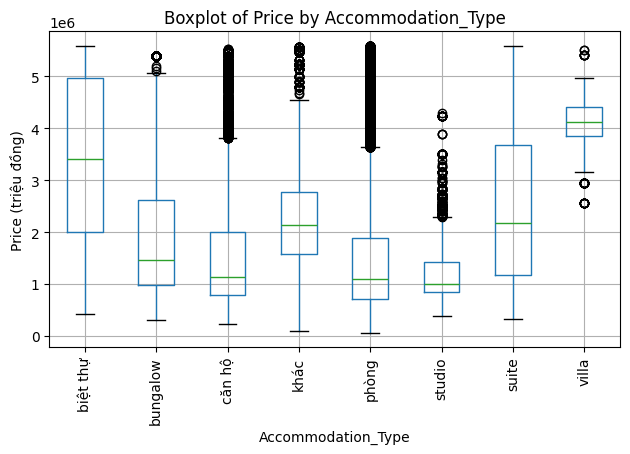

In [ ]:
plt.figure(figsize=(12, 8))
df.boxplot(column='Price', by='Accommodation_Type')
plt.title('Boxplot of Price by Accommodation_Type')
plt.suptitle('') # suppress the default super title
plt.xlabel('Accommodation_Type')
plt.ylabel('Price (triệu đồng)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Tứ phân vị thứ 3 của mỗi nhóm

In [ ]:
quartiles_by_accommodate = df.groupby('Accommodation_Type')['Price'].quantile(0.75)

# Sort the result by the third quartile (0.75) in descending order
quartiles_by_accommodate = quartiles_by_accommodate.sort_values(ascending=False)

quartiles_by_accommodate

,Price
Accommodation_Type,
biệt thự,4968000.00
villa,4400000.00
suite,3668725.00
khác,2772768.75
bungalow,2613600.00
căn hộ,2000000.00
phòng,1875000.00
studio,1430000.00


Dựa vào tứ phân vị thứ 3, ta có thể định nghĩa thứ tự của các loại cư trú từ đó ordinal encode như sau :
- biệt thự
- villa
- suite
- khác
- bungalow
- căn hộ
- phòng
- studio


#### Cột Room_Level

<Figure size 1200x800 with 0 Axes>

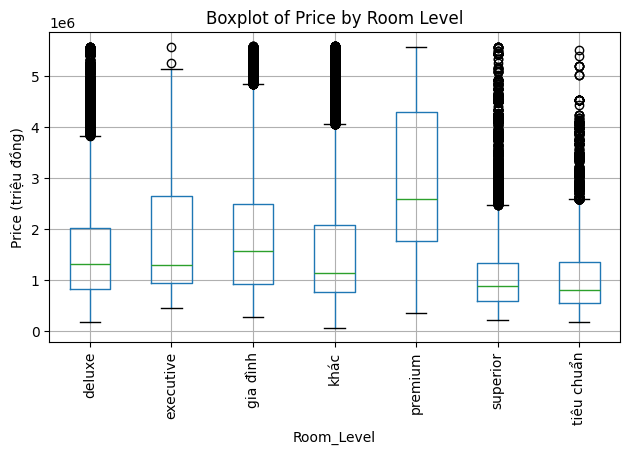

In [ ]:
plt.figure(figsize=(12, 8))
df.boxplot(column='Price', by='Room_Level')
plt.title('Boxplot of Price by Room Level')
plt.suptitle('') # suppress the default super title
plt.xlabel('Room_Level')
plt.ylabel('Price (triệu đồng)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### Tứ phân vị thứ 3 của mỗi nhóm

In [ ]:
quartiles_by_room = df.groupby('Room_Level')['Price'].quantile(0.75)

# Sort the result by the third quartile (0.75) in descending order
quartiles_by_room = quartiles_by_room.sort_values(ascending=False)

quartiles_by_room

,Price
Room_Level,
premium,4290000.0
executive,2648965.0
gia đình,2500000.0
khác,2088000.0
deluxe,2023500.0
tiêu chuẩn,1364580.0
superior,1344600.0


Dựa vào tứ phân vị thứ 3, ta có thể định nghĩa thứ tự của các loại phòng từ đó ordinal encode như sau :
- premium
- executive
- gia đình
- khác
- deluxe
- tiêu chuẩn
- superior

# Feature Selection khi đã EDA

## Xóa những cột có cận dưới của khoảng tin cậy bé hơn 100 000 VDN

In [ ]:
print(remove_cols)

['view_to_beach', 'view_to_river', 'eaves', 'parking', 'is_special_day', 'airport_shuttle']


In [ ]:
for col in remove_cols:
  df.drop(col, axis=1, inplace=True)

## Xóa 6 cột bị đa cộng tuyến

In [ ]:
remove_corr_cols=['evaluate','staff', 'convenient','clean','comfort','worthwhile']
for col in remove_corr_cols:
  df.drop(col, axis=1, inplace =True)

# VIF để kiểm tra hiện tượng đa cộng tuyến sau khi đã feature selection

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Chọn các cột kiểu số
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Loại bỏ cột 'Price' khỏi danh sách các cột kiểm tra VIF vì nó là biến mục tiêu
if 'Price' in numeric_cols:
    numeric_cols.remove('Price')

# Tạo DataFrame chỉ với các cột số còn lại
X = df[numeric_cols]

# Tính VIF cho từng cột
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

# Calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]

print("VIF for numeric columns:")
vif_data

VIF for numeric columns:


,feature,VIF
0,Distance_to_DownTown,2.226725
1,Distance_to_Beach,2.335546
2,Point,1478.571529
3,Evaluate,51.387642
4,Stars,7.727427
5,Rates_Quantity,2.018437
6,view_to_city,2.429075
7,view_to_mountain,1.683928
8,pool,5.249567
9,tourist_spot,12.405064


In [ ]:
# Lọc ra các cột có VIF > 10
high_vif_cols = vif_data[vif_data['VIF'] > 10]['feature'].tolist()

print(f"Các cột có VIF > 10: {high_vif_cols}")

# Loại bỏ các cột có VIF > 10 khỏi DataFrame
df = df.drop(columns=high_vif_cols)


Các cột có VIF > 10: ['Point', 'Evaluate', 'tourist_spot', 'eat_drink_spot', 'beachs', 'destination', 'day', 'month', 'day_range']


# Encode và TFIDF sau khi đã feature selection

## Ordinal Encoder

In [ ]:
# Define the order of categories for each column
accommodation_order = ['resort','biệt thự', 'villa', 'suite', 'khác', 'bungalow', 'căn hộ', 'phòng', 'studio']
room_level_order = ['premium', 'executive', 'gia đình', 'khác', 'deluxe', 'tiêu chuẩn', 'superior']

ordi_encoder = OrdinalEncoder(categories=[accommodation_order, room_level_order])



## Onehot Encoder

In [ ]:
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


## TFIDF và chỉ giữ lại 100 feature để chạy được mô hình

In [ ]:
df['Name'] = df['Name'].astype(str).apply(lambda text : vi_tokenizer(text,format='text'))

tfidf_vectorizer = TfidfVectorizer(max_features=100,  # You can adjust the number of features
                                   tokenizer=lambda x: x.split(' ')        # Ignore terms that appear in less than 5 documents
                                   )      # Ignore terms that appear in more than 80% of documents



# Xây dựng transformer

In [ ]:
transformer=ColumnTransformer(
    transformers=[
        ('ordinal_col', ordi_encoder, ['Accommodation_Type', 'Room_Level']),
        ('onehot_col', onehot_encoder, ['Room/Bed Quantity', 'Address']),
        ('tfidf_col', tfidf_vectorizer, 'Name')
    ],
    remainder='passthrough'
)


In [ ]:
df.shape

(242240, 18)

In [ ]:
df.head()

,Name,Address,Distance_to_DownTown,Distance_to_Beach,Price,Stars,Rates_Quantity,view_to_city,view_to_mountain,pool,Adults,Children,count_nearest_airport,distance_to_nearest_airport,is_weekend,Accommodation_Type,Room_Level,Room/Bed Quantity
0,corgi house,da nang,0.4,1.7,475000.0,0.0,48.0,0.0,0.0,0.0,1,0,2,9.0,0,phòng,superior,1 giường đôi
1,ngoc bich hotel,da nang,1.8,0.0,274580.0,3.0,1555.0,1.0,0.0,1.0,1,0,2,6.0,0,phòng,superior,không rõ
2,la belle vie boutique hotel,da nang,1.3,2.4,508500.0,4.0,430.0,1.0,0.0,1.0,1,0,2,5.0,0,phòng,superior,1 giường đôi
3,lada house,da nang,0.0,2.4,806841.0,0.0,407.0,1.0,0.0,1.0,1,0,2,6.0,0,phòng,deluxe,1 giường đôi
4,dana boutique hotel apartment,da nang,1.4,0.0,594405.0,4.0,147.0,1.0,0.0,1.0,1,0,2,9.0,0,studio,khác,1 giường


In [ ]:
df=transformer.fit_transform(df)

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
df=pd.DataFrame(df,columns=transformer.get_feature_names_out())

In [ ]:
passthrough_cols = [col for col in df.columns if col.startswith('remainder__')]
new_cols = [col.replace('remainder__', '') if col.startswith('remainder__') else col for col in df.columns]
df.columns = new_cols

In [ ]:
df.head()

,ordinal_col__Accommodation_Type,ordinal_col__Room_Level,onehot_col__Room/Bed Quantity_01 giường,onehot_col__Room/Bed Quantity_02 giường,onehot_col__Room/Bed Quantity_1 giường,onehot_col__Room/Bed Quantity_1 giường đôi,onehot_col__Room/Bed Quantity_1 giường đơn,onehot_col__Room/Bed Quantity_1 phòng,onehot_col__Room/Bed Quantity_10 giường,onehot_col__Room/Bed Quantity_12 giường,...,Stars,Rates_Quantity,view_to_city,view_to_mountain,pool,Adults,Children,count_nearest_airport,distance_to_nearest_airport,is_weekend
0,7.0,6.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,48.0,0.0,0.0,0.0,1.0,0.0,2.0,9.0,0.0
1,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,1555.0,1.0,0.0,1.0,1.0,0.0,2.0,6.0,0.0
2,7.0,6.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,4.0,430.0,1.0,0.0,1.0,1.0,0.0,2.0,5.0,0.0
3,7.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,407.0,1.0,0.0,1.0,1.0,0.0,2.0,6.0,0.0
4,8.0,3.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4.0,147.0,1.0,0.0,1.0,1.0,0.0,2.0,9.0,0.0


In [ ]:
df.to_csv('/content/drive/MyDrive/Gold_data.csv', index=False)